In [23]:
    from sklearn.model_selection import train_test_split
    import seaborn as sns
    import pandas as pd
    df=pd.read_csv('../data/cardio_train_clean.csv')
    
    X=df.drop(["cardio","age"], axis=1)
    y=df["cardio"]
    
    # stratify=y will be used to maintain the ration, like if there are 6000 cardio-0, and 4000 cardio-1, 
    # and if 8000 is train test data than 
    # Train set: 60% of 8,000 → 4,800 no disease, 40% of 8,000 → 3,200 disease
    # Test set: 60% of 2,000 → 1,200 no disease, 40% of 2,000 → 800 disease
    X_train, X_test, y_train, y_test=train_test_split(
        X,y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# a model which combines many decision trees
# n_estimators=200
# Number of trees in the forest
# More trees → better stability (but slower)
# 200 is a strong default

rf_model=RandomForestClassifier(
    n_estimators=200,        
    random_state=42,
    max_depth=12,            # limit tree depth
    min_samples_split=20,    # node should have 20 records, than only it can be split
    min_samples_leaf=10,     # after splitting, leafs should have min 10 records
)

# Builds 200 decision trees
# Each tree:
# Sees a random subset of data

rf_model.fit(X_train, y_train)
y_pred=rf_model.predict(X_test)

print(classification_report(y_test,y_pred))

# Precision - When the model predicts a class, how often is it correct?
# for preicision-1----->Of all patients the model predicted “HAS disease”, how many actually had disease?
# Recall - Of patients who actually had disease, how many did we detect?
# F1-score - Harmonic mean of precision & recall
# Balances false positives & false negatives
# Support - Number of samples per class

train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)
print(f"Train Accuracy: {train_acc:.2f}")
print(f"Test Accuracy: {test_acc:.2f}")

#      for model overfiitting ? underfitting
# Overfitting:
# Train ──────────────── 98%
# Test  ──────── 72%

# Underfitting:
# Train ─────── 62%
# Test  ────── 60%

# Good Fit:
# Train ────────── 82%
# Test  ───────── 80%

              precision    recall  f1-score   support

           0       0.72      0.78      0.75      6947
           1       0.75      0.69      0.72      6808

    accuracy                           0.73     13755
   macro avg       0.73      0.73      0.73     13755
weighted avg       0.73      0.73      0.73     13755

Train Accuracy: 0.76
Test Accuracy: 0.73


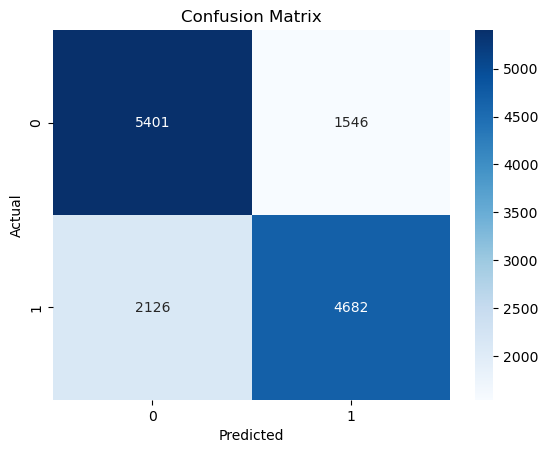

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [31]:
import pickle
with open("rf_model.pkl","wb") as f:
    pickle.dump(rf_model, f)